# 第 14 章 SAC 算法
## 14.1 简介

之前的章节提到过**在线策略算法的采样效率比较低**，通常更倾向于使用离线策略算法。

虽然 DDPG 是离线策略算法，但是它的**训练非常不稳定，收敛性较差，对超参数比较敏感**，也难**以适应不同的复杂环境**。

2018 年，一个更加稳定的离线策略算法 Soft Actor-Critic（SAC）被提出。

SAC 的前身是 Soft Q-learning，它们都属于最大熵强化学习的范畴。
- Soft Q-learning 不存在一个显式的策略函数，而是使用一个函数$Q$的波尔兹曼分布，在连续空间下求解非常麻烦。
- 于是 SAC 提出使用一个 Actor 表示策略函数，从而解决这个问题。目前，在无模型的强化学习算法中，SAC 是一个非常高效的算法，它学习一个随机性策略，在不少标准环境中取得了领先的成绩。

## 14.2 最大熵强化学习
以下内容为图片中相应部分的 Markdown 排版：


**熵（entropy）** 表示对一个**随机变量的随机程度的度量**。

如果 $X$ 是一个随机变量，且它的概率密度函数为 $p$，那么它的熵 $H$ 就被定义为

$$
H(X) = \mathbb{E}_{x\sim p}\left[-\log p(x)\right]
$$

在强化学习中，可以使用 $H(\pi(\cdot|s))$ 来表示策略 $\pi$ 在状态 $s$ 下的随机程度。

### 最大熵强化学习

**最大熵强化学习**（maximum entropy RL）的思想是除了要最大化累积奖励，还要**使得策略更加随机**。强化学习的目标中就加入了一项熵的正则项，定义为

$$
\pi^* = \arg\max_\pi \mathbb{E}_{\pi} \left[\sum_t r(s_t, a_t) + \alpha H(\pi(\cdot|s_t))\right]
$$

$\alpha$ 是一个正则化的系数，用来控制熵的重要程度。

熵正则化增强了强化学习算法的探索程度，$\alpha$ 越大，探索性就越强，有助于加速后续的策略学习，并减少策略陷入较差的局部最优的可能性。
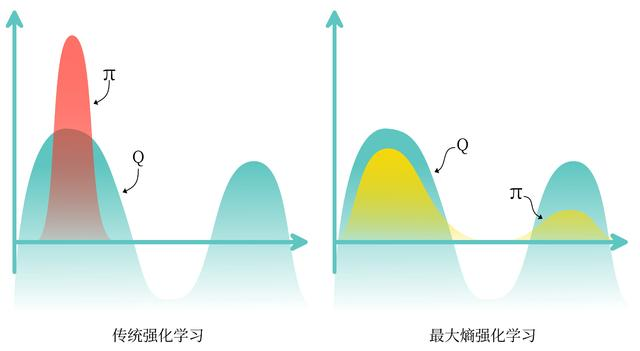

图14-1 传统强化学习和最大熵强化学习的区别+

## 14.3 Soft 策略迭代

在最大熵强化学习框架中，由于目标函数发生了变化，其他的一些定义也有相应的变化。

Soft 贝尔曼方程：

$$
Q(s_t, a_t) = r(s_t, a_t) + \gamma \mathbb{E}_{s_{t+1}}[V(s_{t+1})]
$$

其中，状态价值函数被写为

$$
V(s_t) = \mathbb{E}_{a_t \sim \pi}[Q(s_t, a_t) - \alpha \log \pi(a_t | s_t)] = \mathbb{E}_{a_t \sim \pi}[Q(s_t, a_t)] + H(\pi(\cdot|s_t))
$$

于是，根据该 Soft 贝尔曼方程，在有限的状态和动作空间情况下，Soft 策略评估可以收敛到策略的 Soft Q函数。

然后，根据如下 Soft 策略提升公式可以改进策略：

$$
\pi_{\text{new}} = \arg\min_{\pi'} D_{KL} \left(
\pi'(\cdot|s), \frac{\exp(\frac{1}{\alpha} Q^{\pi_{\text{old}}}(s, \cdot))}{Z^{\pi_{\text{old}}}(s, \cdot)}
\right)
$$
其中，$Z^{\pi_{\text{old}}}(s, \cdot)$ 是一个归一化因子。

重互交替使用 Soft 策略评估和 Soft 策略提升，最终策略可以收敛到最大熵强化学习目标中的最优策略。

但该 Soft 策略迭代方法只适用于表格型（tabular）设置的情况，即状态空间和动作空间是有限的情况。**在连续空间**下，需要**通过参数化函数 Q 和策略**来近似这样的迭代。

## 14.4 SAC
在 SAC 算法中，为两个动作价值函数 $Q$（参数分别为 $\omega_1$ 和 $\omega_2$）和一个策略函数 $\pi$（参数为 $\theta$）建模。

基于 Double DQN 的思想，SAC 使用两个 $Q$ 网络，但每次用 $Q$ 网络时会**挑选一个 $Q$ 值小的网络**，从而缓解 $Q$ 值过高估计的问题。

任意一个函数 $Q$ 的损失函数为：

$$
L_Q(\omega) = \mathbb{E}_{(s_t, a_t, r_t, s_{t+1}) \sim R}
\left[
    \frac{1}{2} \left(Q_\omega(s_t, a_t) - (r_t + \gamma \mathbb{V}_{s_{t+1}}) \right)^2
\right]
$$

$$
= \mathbb{E}_{(s_t, a_t, r_t, s_{t+1}) \sim R, a_{t+1} \sim \pi_{\theta}}
\left[
    \frac{1}{2} \left(
        Q_\omega(s_t, a_t) -
        \left(r_t + \gamma \left(
            \min_{j=1,2} Q_{\omega_j}(s_{t+1}, a_{t+1}) - \alpha \log \pi(a_{t+1} | s_{t+1})
        \right)\right)
    \right)^2
\right]
$$

- $R$ 是策略过去收集的数据,因为 SAC 是一种离线策略算法。
- 为了让训练更加稳定，这里使用了目标 $Q$ 网络 $Q_{\omega'}$，同样是两个目标 $Q$ 网络，与两个 $Q$ 网络一一对应。
- SAC 中目标 $Q$ 网络的更新方式与 DDPG 中的更新方式一样。

策略的损失函数由 KL 散度得到，化简后为：

$$
L_\pi(\theta) = \mathbb{E}_{s_t \sim R, a_t \sim \pi_{\theta}} \left[
    \alpha \log (\pi_{\theta}(a_t | s_t)) - Q_\omega(s_t, a_t)
\right]
$$

可以理解为最大化函数 $V$，因为有
$
V(s_t) = \mathbb{E}_{a_t \sim \pi}[Q(s_t, a_t) - \alpha \log \pi(a_t | s_t)]
$

对**连续动作空间的环境**，SAC算法的策略输出高斯分布的均值和标准差，但是根据高斯分布采样动作的过程是**不可导**的。

因此需要用**重参数化技巧**（reparameterization trick）。
- 重参数化做法是先从一个单位高斯分布 $\mathcal{N}$ 采样，再把采样值乘以标准差后加上均值。
- 这样就可以认为从策略高斯分布采样，并且这个过程对策略参数可导。
- 将其表示为 $a_t = f_{\theta}(\varepsilon_t; s_t)$，
    - 其中 $\varepsilon_t$ 是一个噪声随机变量。
    - 同时考虑到两个函数 $Q$，重写策略的损失函数如下：

$$
L_\pi(\theta) = \mathbb{E}_{s_t \sim R, \varepsilon_t \sim \mathcal{N}}
\left[
    \alpha \log(\pi_{\theta}(f_{\theta}(\varepsilon_t; s_t) | s_t)) - \min_{j=1,2} Q_{\omega_j}(s_t, f_{\theta}(\varepsilon_t; s_t))
\right]
$$



### 自动调整熵正则项

在 SAC 算法中，如何选择**熵正则项的系数**非常重要。

在不同的状态下需要不同大小的熵：
- 在最优动作不确定的某个状态下，熵的取值应该大一点；
- 在某个最优动作比较确定的状态下，熵的取值可以小一点。
- 为了自动调整熵正则项，SAC 将强化学习的目标改写为**一个带约束的优化问题**：
$$
\max_{\pi}\mathbb{E}_\pi\left[\sum_t r(s_t, a_t)\right]\quad\text{s.t. } \mathbb{E}_{(s_t, a_t)\sim \rho_\pi}[-\log \pi(a_t|s_t)] \geq H_0
$$

也就是最大化期望回报，同时约束熵的均值大于$H_0$。

通过一些数学技巧化简后，得到的损失函数为：

$$
L(\alpha) = \mathbb{E}_{s_t, a_t \sim R, a_t \sim \pi_\theta}[-\alpha \log \pi(a_t|s_t) - \alpha H_0]
$$

- 当策略的熵低于目标值$H_0$时, 训练目标是（会使$\alpha$的值增大, 进而在上述最小化损失函数$L_\pi(\theta)$的过程中增强了策略熵对应项的重要性；
- 当策略的熵高于目标值$H_0$时，训练目标（$\alpha$的值减小，进而使得策略训练时更专注于价值提升）。

SAC具体算法流程如下：

- 用随机的网络参数$\omega_1,\omega_2$和$\phi$分别初始化Critic网络$Q_{\omega_1}(s,a), Q_{\omega_2}(s,a)$和Actor网络$\pi_\phi(s)$
- 复制初始化目标网络$\omega_1', \omega_2'$为$\omega_1, \omega_2$，分别初始化目标网络$\omega_1', \omega_2'$
- 初始化经验回放池$\mathcal{D}$
- for 序列$1\rightarrow E$ do
    - 获取环境初始状态$s_1$
    - for 时间步$t=1 \rightarrow T$ do
        - 根据当前策略选择动作$a_t \sim \pi_\phi(s_t)$
        - 执行动作$f(a_t)$，获得奖励$r_t$，环境状态变为$s_{t+1}$
        - 将$(s_t, a_t, r_t, s_{t+1})$ 存入回放池$\mathcal{D}$
    - for 训练轮数$k=1 \rightarrow K$ do
        - 从$\mathcal{D}$中采样N个元组$\{(s_i, a_i, r_i, s_{i+1})\}_{i=1,\cdots,N}$
        - 对每个元组，用目标网络计算
        $$
        y_i = r_i + \gamma \min_{j=1,2} Q_{\omega_j'}(s_{i+1}, a_{i+1}) - \alpha \log \pi_\phi(a_{i+1}|s_{i+1}), \quad \text{其中}~ a_{i+1} \sim \pi_\phi(s_{i+1})
        $$
        - 对两个Critic网络都进行如下更新，对$j=1,2$，最小化损失函数$L=\frac{1}{N}\sum_{i=1}^N (y_i - Q_{\omega_j}(s_i, a_i))^2$
        - 用重参数化技巧采样动作，然后用以下损失函数更新当前Actor网络:
        $$
        L_\pi(\phi) = \frac{1}{N} \sum_{i=1}^N \left(\alpha \log \pi_\phi(\tilde{a}_i|s_i) - \min_{j=1,2} Q_{\omega_j}(s_i, \tilde{a}_i)\right)
        $$
        - 更新熵正则项的系数$\alpha$
        - 更新目标网络:
        $$
        \omega_1' \leftarrow \tau \omega_1 + (1-\tau)\omega_1' \\
        \omega_2' \leftarrow \tau \omega_2 + (1-\tau)\omega_2'
        $$
    - end for
- end for


In [1]:
import random
import gym
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
import sys
sys.path.append('../') # 在上层目录下
import rl_utils

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


接下来定义策略网络和价值网络。

由于处理的是与**连续动作交互的环境**，策略网络输出一个高斯分布的均值和标准差来表示动作分布；
而价值网络的输入是**状态和动作的拼接向量**，输出一个实数来表示动作价值。


In [2]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)
        self.action_bound = action_bound

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        std = F.softplus(self.fc_std(x))
        dist = Normal(mu, std)
        normal_sample = dist.rsample()  # rsample()是重参数化采样
        log_prob = dist.log_prob(normal_sample)
        action = torch.tanh(normal_sample)
        # 计算tanh_normal分布的对数概率密度
        log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)
        action = action * self.action_bound
        return action, log_prob


class QValueNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1)
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)

如 14.4 节所述，SAC 使用两个 Critic 网络 $Q_{\omega_1}$ 和 $Q_{\omega_2}$ 来使 Actor 的训练更稳定，而这两个 Critic 网络在训练时则各自需要一个目标价值网络。

因此，SAC 算法一共用到 5 个网络，分别是一个策略网络、两个价值网络和两个目标价值网络。


In [3]:
class SACContinuous:
    ''' 处理连续动作的SAC算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound,
                 actor_lr, critic_lr, alpha_lr, target_entropy, tau, gamma,
                 device):
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim,
                                         action_bound).to(device)  # 策略网络
        self.critic_1 = QValueNetContinuous(state_dim, hidden_dim,
                                            action_dim).to(device)  # 第一个Q网络
        self.critic_2 = QValueNetContinuous(state_dim, hidden_dim,
                                            action_dim).to(device)  # 第二个Q网络
        self.target_critic_1 = QValueNetContinuous(state_dim,
                                                   hidden_dim, action_dim).to(
                                                       device)  # 第一个目标Q网络
        self.target_critic_2 = QValueNetContinuous(state_dim,
                                                   hidden_dim, action_dim).to(
                                                       device)  # 第二个目标Q网络
        # 令目标Q网络的初始参数和Q网络一样
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(),
                                                   lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(),
                                                   lr=critic_lr)
        # 使用alpha的log值,可以使训练结果比较稳定
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True  # 可以对alpha求梯度
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha],
                                                    lr=alpha_lr)
        self.target_entropy = target_entropy  # 目标熵的大小
        self.gamma = gamma
        self.tau = tau
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        action = self.actor(state)[0]
        return [action.item()]

    def calc_target(self, rewards, next_states, dones):  # 计算目标Q值
        next_actions, log_prob = self.actor(next_states)
        entropy = -log_prob
        q1_value = self.target_critic_1(next_states, next_actions)
        q2_value = self.target_critic_2(next_states, next_actions)
        next_value = torch.min(q1_value,
                               q2_value) + self.log_alpha.exp() * entropy
        td_target = rewards + self.gamma * next_value * (1 - dones)
        return td_target

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(),
                                       net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) +
                                    param.data * self.tau)

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)
        # 和之前章节一样,对倒立摆环境的奖励进行重塑以便训练
        rewards = (rewards + 8.0) / 8.0

        # 更新两个Q网络
        td_target = self.calc_target(rewards, next_states, dones)
        critic_1_loss = torch.mean(
            F.mse_loss(self.critic_1(states, actions), td_target.detach()))
        critic_2_loss = torch.mean(
            F.mse_loss(self.critic_2(states, actions), td_target.detach()))
        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()
        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()

        # 更新策略网络
        new_actions, log_prob = self.actor(states)
        entropy = -log_prob
        q1_value = self.critic_1(states, new_actions)
        q2_value = self.critic_2(states, new_actions)
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy -
                                torch.min(q1_value, q2_value))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # 更新alpha值
        alpha_loss = torch.mean(
            (entropy - self.target_entropy).detach() * self.log_alpha.exp())
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)

In [4]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # 动作最大值
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100
hidden_dim = 128
gamma = 0.99
tau = 0.005  # 软更新参数
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = SACContinuous(state_dim, hidden_dim, action_dim, action_bound,
                      actor_lr, critic_lr, alpha_lr, target_entropy, tau,
                      gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size)

Iteration 0:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\10240\AppData\Local\Temp\ipykernel_70588\3112454918.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 10/10 [00:29<00:00,  2.97s/it, episode=100, return=-185.529]


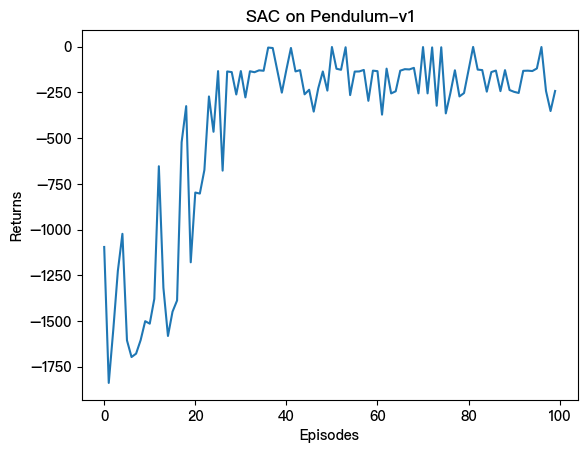

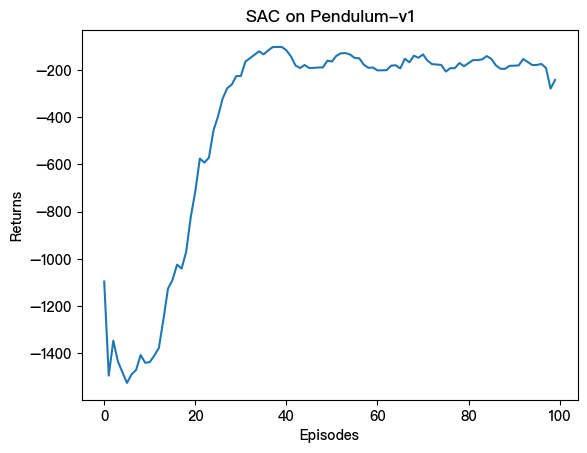

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

SAC 在倒立摆环境中的表现非常出色。

SAC 算法原本是针对连续动作交互的环境提出的，那一个比较自然的问题便是：
- SAC 能否处理与离散动作交互的环境呢？首先，策略网络和价值网络的网络结构将发生如下改变：
    - 策略网络的**输出修改为在离散动作空间上**的 softmax 分布；
    - 价值网络直接**接收状态**和**离散动作空间**的分布作为输入。

In [6]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)


class QValueNet(torch.nn.Module):
    ''' 只有一层隐藏层的Q网络 '''
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

该策略网络输出一个离散的动作分布，所以在价值网络的学习过程中，不需要再对下一个动作$a_{t+1}$进行采样，而是直接通过概率计算来得到下一个状态的价值。

同理，在$\alpha$的损失函数计算中，也不需要再对动作进行采样。

In [7]:
class SAC:
    ''' 处理离散动作的SAC算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 alpha_lr, target_entropy, tau, gamma, device):
        # 策略网络
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        # 第一个Q网络
        self.critic_1 = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        # 第二个Q网络
        self.critic_2 = QValueNet(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_1 = QValueNet(state_dim, hidden_dim,
                                         action_dim).to(device)  # 第一个目标Q网络
        self.target_critic_2 = QValueNet(state_dim, hidden_dim,
                                         action_dim).to(device)  # 第二个目标Q网络
        # 令目标Q网络的初始参数和Q网络一样
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(),
                                                   lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(),
                                                   lr=critic_lr)
        # 使用alpha的log值,可以使训练结果比较稳定
        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float)
        self.log_alpha.requires_grad = True  # 可以对alpha求梯度
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha],
                                                    lr=alpha_lr)
        self.target_entropy = target_entropy  # 目标熵的大小
        self.gamma = gamma
        self.tau = tau
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()

    # 计算目标Q值,直接用策略网络的输出概率进行期望计算
    def calc_target(self, rewards, next_states, dones):
        next_probs = self.actor(next_states)
        next_log_probs = torch.log(next_probs + 1e-8)
        entropy = -torch.sum(next_probs * next_log_probs, dim=1, keepdim=True)
        q1_value = self.target_critic_1(next_states)
        q2_value = self.target_critic_2(next_states)
        min_qvalue = torch.sum(next_probs * torch.min(q1_value, q2_value),
                               dim=1,
                               keepdim=True)
        next_value = min_qvalue + self.log_alpha.exp() * entropy
        td_target = rewards + self.gamma * next_value * (1 - dones)
        return td_target

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(),
                                       net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) +
                                    param.data * self.tau)

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)  # 动作不再是float类型
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        # 更新两个Q网络
        td_target = self.calc_target(rewards, next_states, dones)
        critic_1_q_values = self.critic_1(states).gather(1, actions)
        critic_1_loss = torch.mean(
            F.mse_loss(critic_1_q_values, td_target.detach()))
        critic_2_q_values = self.critic_2(states).gather(1, actions)
        critic_2_loss = torch.mean(
            F.mse_loss(critic_2_q_values, td_target.detach()))
        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()
        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()

        # 更新策略网络
        probs = self.actor(states)
        log_probs = torch.log(probs + 1e-8)
        # 直接根据概率计算熵
        entropy = -torch.sum(probs * log_probs, dim=1, keepdim=True)  #
        q1_value = self.critic_1(states)
        q2_value = self.critic_2(states)
        min_qvalue = torch.sum(probs * torch.min(q1_value, q2_value),
                               dim=1,
                               keepdim=True)  # 直接根据概率计算期望
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy - min_qvalue)
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # 更新alpha值
        alpha_loss = torch.mean(
            (entropy - target_entropy).detach() * self.log_alpha.exp())
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)

In [8]:
actor_lr = 1e-3
critic_lr = 1e-2
alpha_lr = 1e-2
num_episodes = 200
hidden_dim = 128
gamma = 0.98
tau = 0.005  # 软更新参数
buffer_size = 10000
minimal_size = 500
batch_size = 64
target_entropy = -1
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = SAC(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, alpha_lr,
            target_entropy, tau, gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size)

D:\DevelopmentSoftware\Anaconda\envs\py311\Lib\site-packages\gym\envs\registration.py:505: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1` with the environment ID `CartPole-v1`.
  logger.warn(
Iteration 9: 100%|██████████| 20/20 [00:32<00:00,  1.62s/it, episode=200, return=194.000]


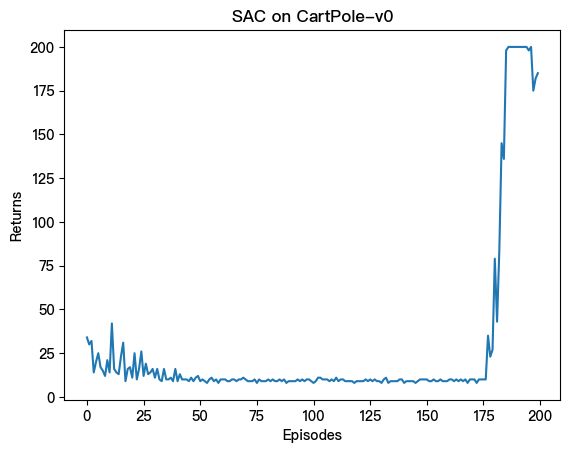

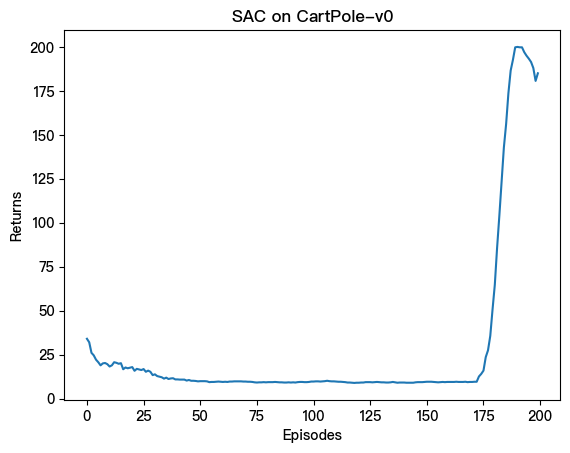

In [9]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()